In [1]:
import mne
import numpy as np
from numpy import matlib as mb
import matplotlib.pyplot as plt
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
import warnings
from collections import defaultdict
import matplotlib.pyplot as plt
from mne.preprocessing import ICA
from mne.preprocessing import Xdawn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, ConfusionMatrixDisplay
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LinearRegression
from scipy.stats import t
from sklearn import metrics
from sklearn.metrics import roc_auc_score as get_auc
from models.LDA import LDAClassifier
from src.Speller import Speller
from src.Dataset import Dataset
warnings.filterwarnings("ignore", category=RuntimeWarning)
mne.set_log_level("WARNING")

Visualizing EEG Data For the 1st Epoch

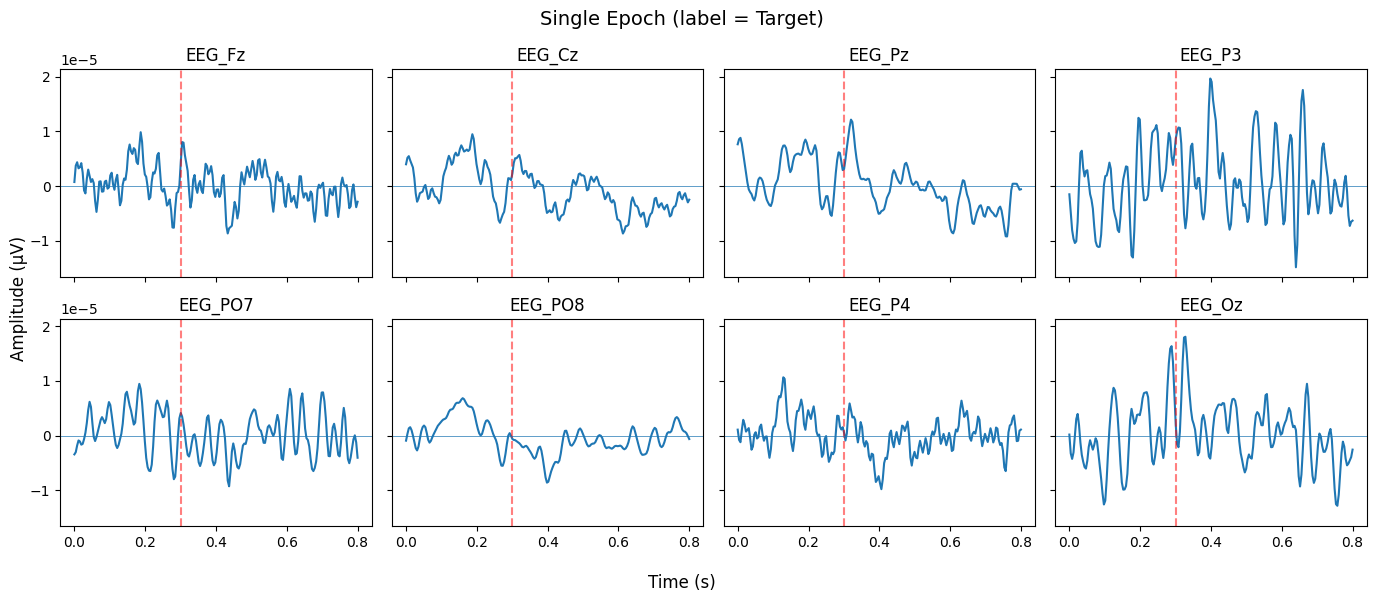

In [2]:
# identified from previous research
important_channels = ['EEG_Fz', 'EEG_Cz', 'EEG_Pz', 'EEG_P3','EEG_PO7', 'EEG_PO8', 'EEG_P4', 'EEG_Oz'] 


# Use All Default values
ds = Dataset(
    glob_path=os.path.join(project_root, "data", "*", "*", "*", "CB", "*"),
    tmin=0,
    tmax=0.8, #detection window
)

X, y = ds[0]
times = np.linspace(ds.tmin, ds.tmax, X.shape[2])

X_target = X[y == 1]
X_nontarget = X[y == 0]
erp_target = X_target.mean(axis=0)
erp_nontarget = X_nontarget.mean(axis=0)

epoch_data = X[0]
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
for ch_idx, ax in enumerate(axes.flatten()):
    ax.plot(times, epoch_data[ch_idx])
    ax.set_title(important_channels[ch_idx])
    ax.axvline(0.3, linestyle="--", alpha=0.5, color='red')
    ax.axhline(0, linewidth=0.5)
fig.suptitle(f"Single Epoch (label = {'Target' if y[0] == 1 else 'Non-target'})", fontsize=14)
fig.supxlabel("Time (s)")
fig.supylabel("Amplitude (µV)")
plt.tight_layout()
plt.show()

Visualizing Classes and Whether or Not they are Imbalanced

In [3]:
print("Target epochs:", X_target.shape[0])
print("Non-target epochs:", X_nontarget.shape[0])

Target epochs: 84
Non-target epochs: 672


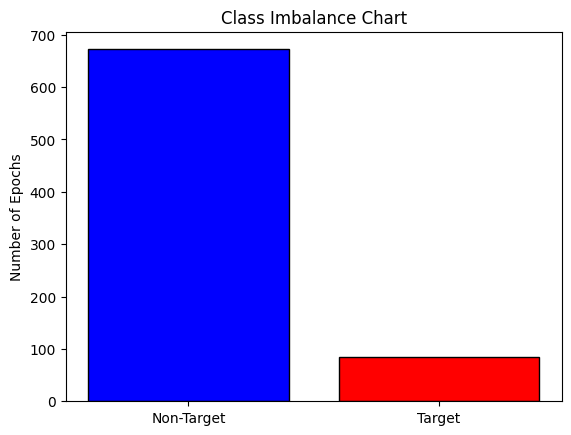

In [4]:
counts = [X_nontarget.shape[0], X_target.shape[0]]
plt.bar(['Non-Target', 'Target'], counts, color=['blue', 'red'], edgecolor='black')
plt.title(f"Class Imbalance Chart")
plt.ylabel("Number of Epochs")
plt.show()

Clear showcase that there is a huge Class Imbalance. 

Visualizing Target vs NonTarget on Average for the First File

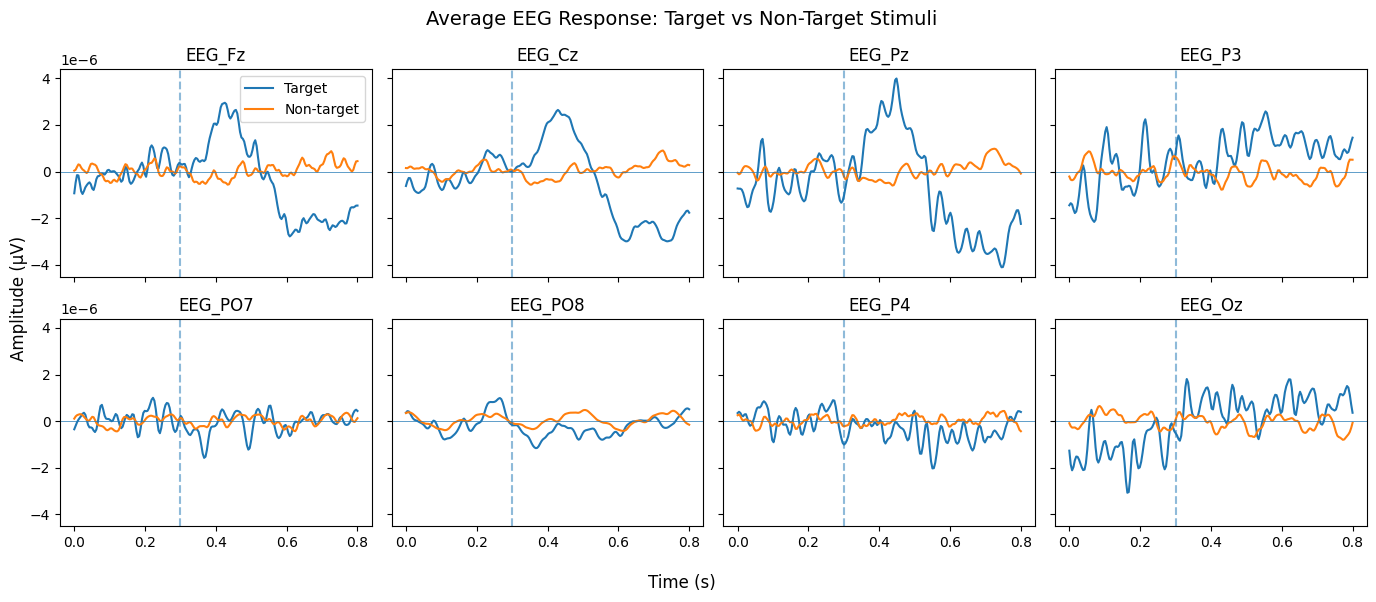

In [5]:
target = X_target.mean(axis=0) # shape: (8, 206)
nontarget = X_nontarget.mean(axis=0)
fig, axes = plt.subplots(2, 4, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.flatten()

for ch_idx, ax in enumerate(axes):
    ax.plot(times, target[ch_idx], label="Target")
    ax.plot(times, nontarget[ch_idx], label="Non-target")
    ax.set_title(important_channels[ch_idx])
    ax.axvline(0.3, linestyle="--", alpha=0.5)
    ax.axhline(0, linewidth=0.5)

axes[0].legend(loc="upper right")
fig.suptitle("Average EEG Response: Target vs Non-Target Stimuli", fontsize=14)
fig.supxlabel("Time (s)")
fig.supylabel("Amplitude (µV)")
plt.tight_layout()
plt.show()

Visualize Provided Spelling Data

In [22]:
print("Target string for this session:", ds.target_string)
print("Character channels:", ds.character_channels)
print("Stim events shape:", ds.stim_events.shape)
print(ds.stim_events)
print("Current target events shape:", ds.current_target_events.shape)
print(ds.current_target_events)

# Extract data
char_labels = ds.character_channels
target_events = ds.current_target_events
stim_events = ds.stim_events
target_string = ds.target_string

# Grid dimensions
grid_size = int(np.sqrt(len(char_labels)))
row_count = grid_size
col_count = grid_size

# Create character grid
char_grid = [ch[0] for ch in char_labels]
char_grid = np.array(char_grid).reshape(grid_size, grid_size)

Target string for this session: PLENTY
Character channels: ['A_1_1', 'B_1_2', 'C_1_3', 'D_1_4', 'E_1_5', 'F_1_6', 'G_2_1', 'H_2_2', 'I_2_3', 'J_2_4', 'K_2_5', 'L_2_6', 'M_3_1', 'N_3_2', 'O_3_3', 'P_3_4', 'Q_3_5', 'R_3_6', 'S_4_1', 'T_4_2', 'U_4_3', 'V_4_4', 'W_4_5', 'X_4_6', 'Y_5_1', 'Z_5_2', 'Sp_5_3', '1_5_4', '2_5_5', '3_5_6', '4_6_1', '5_6_2', '6_6_3', '7_6_4', '8_6_5', '9_6_6']
Stim events shape: (756, 3)
[[ 1160     0     1]
 [ 1224     0     0]
 [ 1288     0     0]
 ...
 [53832     0     1]
 [53896     0     0]
 [53960     0     0]]
Current target events shape: (6, 3)
[[ 1160     0    16]
 [10120     0    12]
 [19080     0     5]
 [28040     0    14]
 [37000     0    20]
 [45960     0    25]]
